# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

Caso:
    Over sampled usando 80% del dataset en train, %20 en val

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [58]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

# One Hot Encoding 15


In [59]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df_ref.sort_values(by="fam", ascending=False, inplace=True)
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref


PATH_OH = "SILVER/test_tables_ov/OneHot_val20_15_epochs_test.csv"
df, df_ref = get_data(PATH_OH)

display(df)
display(df_ref)

/tmp/ipykernel_3301388/3269215223.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.165647,0.170648,0.164711,0.172321,0.172063,0.159586,0.173679,0.171130,0.153062
1,23s,0.238901,0.233489,0.205994,0.245580,0.227753,0.205827,0.206960,0.214750,0.213082
2,5s,0.283302,0.275457,0.250736,0.241849,0.248317,0.267937,0.258017,0.250762,0.263742
3,RNaseP,0.222964,0.205807,0.210350,0.229600,0.221200,0.206054,0.234030,0.221594,0.201759
4,grp1,0.190808,0.180444,0.181166,0.179180,0.188336,0.176761,0.179401,0.189395,0.189251
5,srp,0.139832,0.147569,0.156721,0.149768,0.161466,0.143897,0.148482,0.157047,0.133513
6,tRNA,0.333238,0.381570,0.390417,0.383106,0.397043,0.364986,0.355539,0.386568,0.372797
7,telomerase,0.141106,0.139602,0.135177,0.144303,0.142394,0.125742,0.126732,0.120201,0.138780
8,tmRNA,0.196592,0.201813,0.168256,0.193758,0.204948,0.182499,0.199256,0.186098,0.180544


,fam,famfold
8,tmRNA,0.167492
7,telomerase,0.114144
6,tRNA,0.465288
5,srp,0.165332
4,grp1,0.166082
3,RNaseP,0.183204
2,5s,0.281220
1,23s,0.209476
0,16s,0.152518


In [60]:
{
    "tmRNA": 0.1674917037517465,
    "telomerase": 0.114144392347629,
    "tRNA": 0.4652880783918064,
    "srp": 0.1653320431133,
    "grp1": 0.166081503499135,
    "RNaseP": 0.1832035462839154,
    "5s": 0.2812198125337743,
    "23s": 0.209475822929747,
    "16s": 0.1525179511457889,
}

{'tmRNA': 0.1674917037517465,
 'telomerase': 0.114144392347629,
 'tRNA': 0.4652880783918064,
 'srp': 0.1653320431133,
 'grp1': 0.166081503499135,
 'RNaseP': 0.1832035462839154,
 '5s': 0.2812198125337743,
 '23s': 0.209475822929747,
 '16s': 0.1525179511457889}

In [61]:
df_ref.set_index("fam")["famfold"].to_dict()

{'tmRNA': 0.1674917037517465,
 'telomerase': 0.114144392347629,
 'tRNA': 0.4652880783918064,
 'srp': 0.1653320431133,
 'grp1': 0.166081503499135,
 'RNaseP': 0.1832035462839154,
 '5s': 0.2812198125337743,
 '23s': 0.209475822929747,
 '16s': 0.1525179511457889}

In [62]:
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [63]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})

s.to_csv("SILVER/rel_f1_tables_ov/OneHot_15_epochs_relf1.csv")
s

,modelo,rel_f1
0,rnadist_400,1.001857
1,samples_400,1.011326
2,hc_400,1.018862
3,samples_200,1.037077
4,samples_100,1.040443
5,hc_200,1.062606
6,hc_100,1.063531
7,rnadist_100,1.071620
8,rnadist_200,1.082319


In [64]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

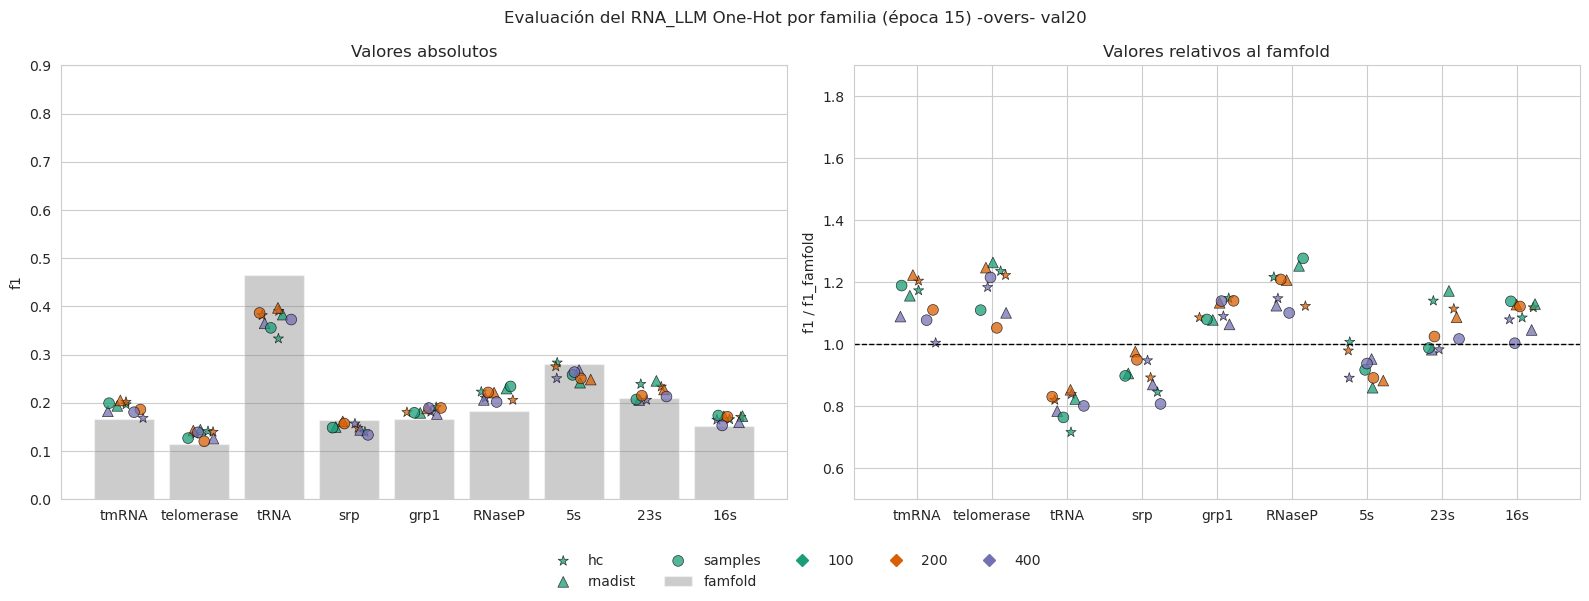

In [65]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del RNA_LLM One-Hot por familia (época 15) -overs- val20")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [66]:
print(dfl)

           fam       modelo        f1   metodo umbral
0          16s       hc_100  0.165647       hc    100
1          23s       hc_100  0.238901       hc    100
2           5s       hc_100  0.283302       hc    100
3       RNaseP       hc_100  0.222964       hc    100
4         grp1       hc_100  0.190808       hc    100
..         ...          ...       ...      ...    ...
76        grp1  samples_400  0.189251  samples    400
77         srp  samples_400  0.133513  samples    400
78        tRNA  samples_400  0.372797  samples    400
79  telomerase  samples_400  0.138780  samples    400
80       tmRNA  samples_400  0.180544  samples    400

[81 rows x 5 columns]


# RiNALMo

In [67]:
PATH_RiNALMo = "SILVER/test_tables_ov/RiNALMo_val20_15_epochs_test.csv"
df, df_ref = get_data(PATH_RiNALMo)

display(df)
display(df_ref)

/tmp/ipykernel_3301388/3269215223.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.480309,0.504731,0.505145,0.458192,0.495003,0.477525,0.485068,0.469235,0.493967
1,23s,0.556551,0.584800,0.620886,0.526856,0.600022,0.614504,0.593622,0.580956,0.602602
2,5s,0.741980,0.758109,0.770009,0.713456,0.758205,0.775638,0.712794,0.676934,0.754466
3,RNaseP,0.593268,0.646212,0.640336,0.589957,0.636697,0.663149,0.605855,0.620496,0.630230
4,grp1,0.536684,0.494429,0.555306,0.482075,0.543685,0.556137,0.511188,0.509338,0.542711
5,srp,0.547674,0.551228,0.580122,0.549019,0.531469,0.583190,0.551670,0.555714,0.591854
6,tRNA,0.855418,0.864722,0.861802,0.825414,0.832716,0.855405,0.860813,0.862959,0.866797
7,telomerase,0.109265,0.097837,0.098872,0.099375,0.098960,0.102459,0.083427,0.068878,0.108823
8,tmRNA,0.564861,0.607493,0.628625,0.552721,0.593302,0.640032,0.608832,0.611575,0.590897


,fam,famfold
8,tmRNA,0.620926
7,telomerase,0.090693
6,tRNA,0.835476
5,srp,0.586522
4,grp1,0.474777
3,RNaseP,0.653999
2,5s,0.739421
1,23s,0.573340
0,16s,0.509853


In [68]:
# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)

dfn = normalizar_y_melt(df, df_ref, experiments)
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})

s.to_csv("SILVER/rel_f1_tables_ov/RiNALMo_15_epochs_relf1.csv")
s

,modelo,rel_f1
0,samples_200,0.955050
1,rnadist_100,0.956648
2,samples_100,0.980571
3,hc_100,1.002877
4,hc_200,1.010742
5,rnadist_200,1.012334
6,samples_400,1.038344
7,hc_400,1.042996
8,rnadist_400,1.046823


In [69]:
dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados

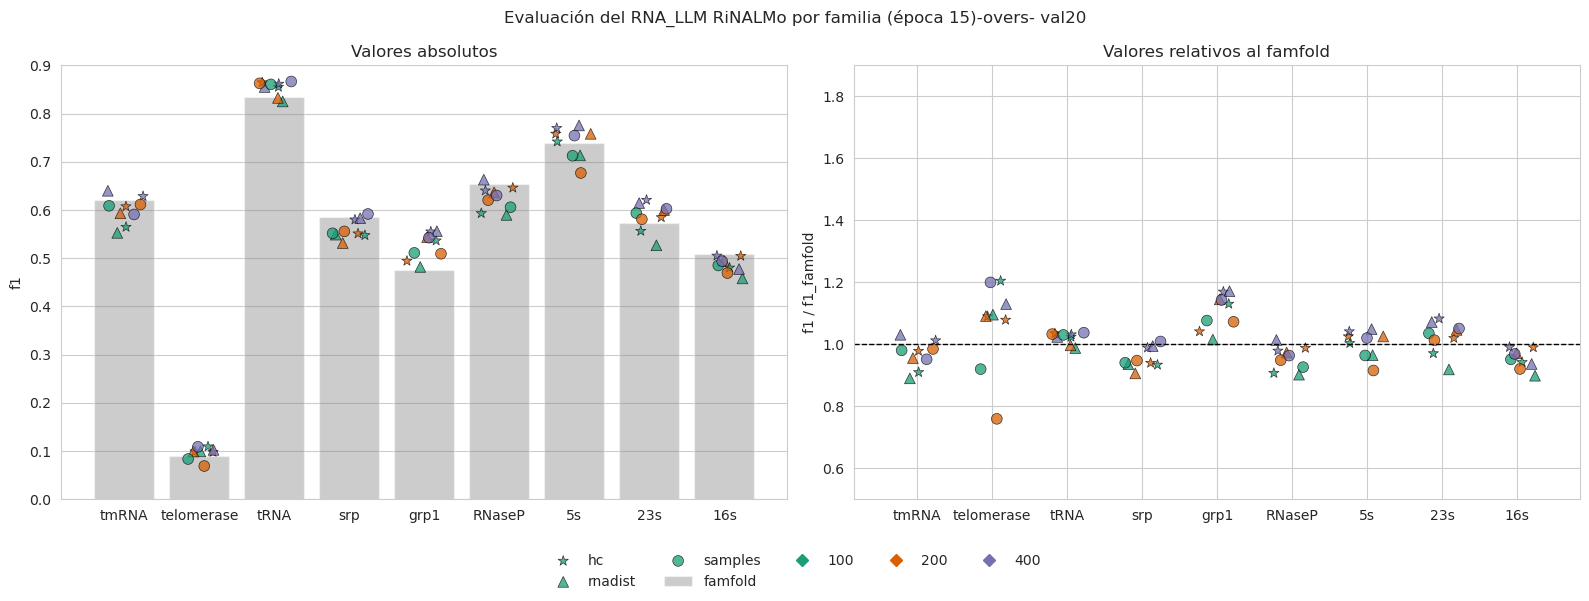

In [70]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del RNA_LLM RiNALMo por familia (época 15)-overs- val20")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()